# ***Introduction***

This project analyzes Airbnb listings to understand pricing, demand patterns, and host performance across New York City using exploratory data analysis and feature engineering.

*This includes:*

1.   Data cleaning and preparation
2.   Feature engineering
3.   Exploratory analysis
4.   Visualizations
5.   Interpretation of results

***Importing and understanding data***

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Airbnb_Open_Data.csv to Airbnb_Open_Data (3).csv


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("Airbnb_Open_Data.csv")
df.info()
df.describe()

/tmp/ipython-input-2886536708.py:1: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Airbnb_Open_Data.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

,id,host id,lat,long,Construction year,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365
count,1.025990e+05,1.025990e+05,102591.000000,102591.000000,102385.000000,102190.000000,102416.000000,86720.000000,102273.000000,102280.000000,102151.000000
mean,2.914623e+07,4.925411e+10,40.728094,-73.949644,2012.487464,8.135845,27.483743,1.374022,3.279106,7.936605,141.133254
std,1.625751e+07,2.853900e+10,0.055857,0.049521,5.765556,30.553781,49.508954,1.746621,1.284657,32.218780,135.435024
min,1.001254e+06,1.236005e+08,40.499790,-74.249840,2003.000000,-1223.000000,0.000000,0.010000,1.000000,1.000000,-10.000000
25%,1.508581e+07,2.458333e+10,40.688740,-73.982580,2007.000000,2.000000,1.000000,0.220000,2.000000,1.000000,3.000000
50%,2.913660e+07,4.911774e+10,40.722290,-73.954440,2012.000000,3.000000,7.000000,0.740000,3.000000,1.000000,96.000000
75%,4.320120e+07,7.399650e+10,40.762760,-73.932350,2017.000000,5.000000,30.000000,2.000000,4.000000,2.000000,269.000000
max,5.736742e+07,9.876313e+10,40.916970,-73.705220,2022.000000,5645.000000,1024.000000,90.000000,5.000000,332.000000,3677.000000


In [ ]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


***Cleaning data***

In [ ]:
df.drop_duplicates(inplace = True)

In [ ]:
df.isna().mean() * 100

,0
id,0.000000
NAME,0.244959
host id,0.000000
host_identity_verified,0.283172
host name,0.395853
neighbourhood group,0.028415
neighbourhood,0.015677
lat,0.007839
long,0.007839
country,0.521272


In [ ]:
df.drop(columns=["license", "house_rules", "NAME", "host name", "id", "host id"], inplace=True)

In [ ]:
df.dropna(subset= ["lat","long","cancellation_policy"],inplace= True)
for i in ["instant_bookable","host_identity_verified"]:
  df[i] = df[i].fillna(df[i].mode()[0])

/tmp/ipython-input-1353346140.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[i] = df[i].fillna(df[i].mode()[0])


In [ ]:
df.loc[df["availability 365"] <0, "availability 365"] = 0
df.loc[df["availability 365"]>365, "availability 365"] = 365
df.loc[df["minimum nights"] <0, "minimum nights"] = 0

In [ ]:
for i in ["availability 365","Construction year","review rate number"]:
  df[i] = df[i].fillna(df[i].median())

In [ ]:
df["country"].value_counts()
df["neighbourhood group"].value_counts()
df[df["neighbourhood group"] == "brookln"]
df.loc[13,"neighbourhood group"] = "Brooklyn"
df[df["neighbourhood group"] == "manhatan"]
df.loc[18,"neighbourhood group"] = "Manhattan"
df[df[["country", "neighbourhood group","neighbourhood","country code"]].isna().all(axis=1)].shape[0]
df.drop(["country", "country code"], axis=1, inplace=True)
for i in ["neighbourhood group","neighbourhood"]:
  df[i] = df[i].fillna(df[i].mode()[0])



In [ ]:
from datetime import datetime
df["last review"] = pd.to_datetime(df["last review"])
df.loc[df["last review"].isna(), "number of reviews"].value_counts()
df.loc[df["reviews per month"].isna(), "number of reviews"].value_counts()
df["reviews per month"] = df["reviews per month"].fillna(0)
df = df[(df["last review"].dt.year >= 2003) & (df["last review"].dt.year <= 2022)]

In [ ]:
df["price"] = df["price"].str.replace('$','').str.replace(',','').astype(float)
df["service fee"] = df["service fee"].str.replace('$','').astype(float)



In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

numcol = ["price","service fee","minimum nights","calculated host listings count","number of reviews"]
scale = StandardScaler()
scaled = scale.fit_transform(df[numcol])
impute= KNNImputer(n_neighbors=5)
imputed = impute.fit_transform(scaled)
df[numcol] = pd.DataFrame(scale.inverse_transform(imputed), columns=numcol)

for i in numcol:
  df[i] = df[i].fillna(df[i].median())

Extra columns

In [ ]:
df["Construction year"].max()
df["Age"] = 2022- df["Construction year"]

In [ ]:
def host_experience(count):
    if count <= 1:
        return "inexperienced"
    elif count <= 5:
        return "intermediate"
    else:
        return "professional"

df["host_experience"] = df["calculated host listings count"].apply(host_experience)

In [ ]:
df["Review score"] = df["reviews per month"] * df["review rate number"]

In [ ]:
df["minimum profit"] = df["price"] * df["minimum nights"]
df["turnover ratio"] = df["reviews per month"] / df["minimum nights"]
df["combined revenue"] = df["minimum profit"] * df["turnover ratio"]

In [ ]:
df.isna().mean() * 100

,0
host_identity_verified,0.0
neighbourhood group,0.0
neighbourhood,0.0
lat,0.0
long,0.0
instant_bookable,0.0
cancellation_policy,0.0
room type,0.0
Construction year,0.0
price,0.0


***Visualization***

In [ ]:
corrmatrix = df.corr(numeric_only=True)
print(corrmatrix)

                                     lat      long  instant_bookable  \
lat                             1.000000  0.075830          0.000450   
long                            0.075830  1.000000         -0.004020   
instant_bookable                0.000450 -0.004020          1.000000   
Construction year               0.006489  0.000323          0.001229   
price                           0.008468  0.005546         -0.003121   
service fee                     0.008414  0.005603         -0.003086   
minimum nights                 -0.007222  0.001695          0.000320   
number of reviews               0.002717 -0.003631         -0.006357   
reviews per month              -0.019659  0.119136          0.001923   
review rate number             -0.004575  0.016448          0.003220   
calculated host listings count -0.004128  0.010885          0.004404   
availability 365               -0.014917  0.075865         -0.005145   
Age                            -0.006489 -0.000323         -0.00

Most numeric categories do not have any correlation. However, price and service fee are heavily positively related (both increase and decrease togther).

Text(0.5, 1.0, 'Distrubution of room types across neighbourhood groups')

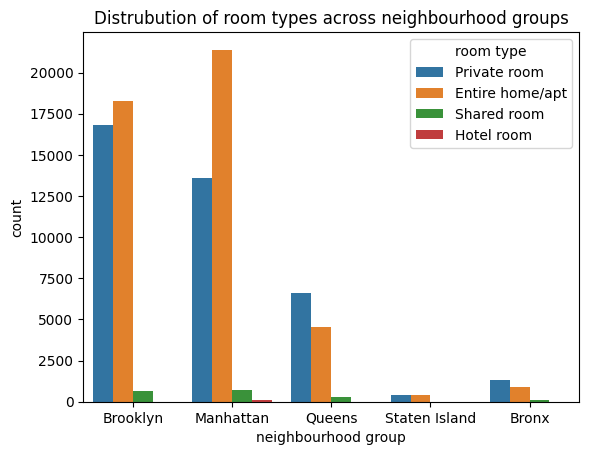

In [ ]:
sns.countplot(x="neighbourhood group", hue="room type", data=df)
plt.title("Distrubution of room types across neighbourhood groups")

In [ ]:
print(df["lat"].min())
print(df["long"].min())
print(df["lat"].max())
print(df["long"].max())
print(df["neighbourhood group"].value_counts())
colors = {"Manhattan":"red","Brooklyn":"orange","Queens":"yellow","Bronx":"green","Staten Island":"blue"}


import folium
map = folium.Map()
map.fit_bounds([[40.50456, -74.24984], [40.91697, -73.70522]])

for _, row in df.head(1000).iterrows():
    folium.CircleMarker(location=[row["lat"], row["long"]],radius=4,color=colors[row["neighbourhood group"]],fill=True,fill_opacity=0.67).add_to(map)
map


40.50456
-74.24984
40.91697
-73.70522
neighbourhood group
Manhattan        35793
Brooklyn         35730
Queens           11435
Bronx             2344
Staten Island      845
Name: count, dtype: int64


In [ ]:
df.groupby("room type")["Review score"].describe()

,count,mean,std,min,25%,50%,75%,max
room type,,,,,,,,
Entire home/apt,45571.0,4.404547,5.971923,0.00,0.62,2.08,6.050,235.55
Hotel room,115.0,10.046435,21.794204,0.08,0.78,2.15,6.975,132.32
Private room,38762.0,4.796075,7.304061,0.00,0.64,2.28,6.400,360.00
Shared room,1699.0,4.677716,5.712335,0.02,0.72,2.68,6.565,53.85


Figure 1 indicates that Manhattan and Brooklyn have the highest number of listings, followed by Queens, Bronx and Staten Island. Major attractions such as Times Square and Central Park are located in Manhattan, which can explain the densely populated lisiting in Manhattan as close proximity to attractions may be a feature AirBnB users find convenient. Figure 2 also offers a geographic visalisation of the spread of lisiting, which demonstrates clusters of listings concentrated around Williamsburg Bridge, suggesting transportation may play a role in listing location as it can faciliate accesbility to various boroughs,for example between Manhattan and Brooklyn. This may also explain the lack of lisitng in Staten Island, where connectivity may prove more difficult, due to its geograpahical isolation from the other boroughs.

Figure 1 also shows that entire home/apt listing is the most common, followed by private rooms, shared rooms and lastly, hotel rooms. The lack of hotel room listings may suggest that hotel rooms are not often listed on Airbnb, as they may be listed on alternative booking platforms, suggesting that they are underepresented on Airbnb.
Additionally, shared rooms have a very low maximum review score of 53.85, indicating that satisfaction is limited, possibly due to the lack of privacy they have to offer.


> ***Minimum nights analysis***



In [ ]:
from scipy.stats import zscore
df["zscore"] = zscore(df["minimum nights"])
df = df[df["zscore"]<=3]

In [ ]:
df["minimum nights"].describe()

,minimum nights
count,8.577900e+04
mean,6.101267e+00
std,9.215648e+00
min,8.881784e-16
25%,2.000000e+00
50%,3.000000e+00
75%,4.000000e+00
max,8.800000e+01


Text(0.5, 1.0, 'Minimum nights distribution')

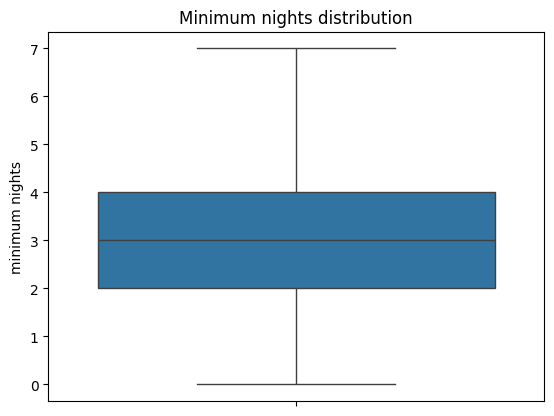

In [ ]:
sns.boxplot(y=df["minimum nights"],showfliers=False)
plt.title("Minimum nights distribution")

The minimum nights of stay has a median of 3, with interquartile values of 2-4 days as shown in the box plot.This suggests that most listings require relatively short stays. The patterns of how the accommodation type affects the minimum nights are shown below.

In [ ]:
df.groupby("room type")["minimum nights"].describe()

,count,mean,std,min,25%,50%,75%,max
room type,,,,,,,,
Entire home/apt,45373.0,6.345822,9.492724,8.881784e-16,2.0,3.0,4.0,88.0
Hotel room,115.0,10.400000,12.427191,1.000000e+00,2.0,3.0,30.0,44.0
Private room,38597.0,5.835459,8.900408,8.881784e-16,2.0,3.0,4.0,88.0
Shared room,1694.0,5.315466,8.159936,1.000000e+00,2.0,3.0,4.0,60.0


Text(0.5, 1.0, 'Minimum nights by room types')

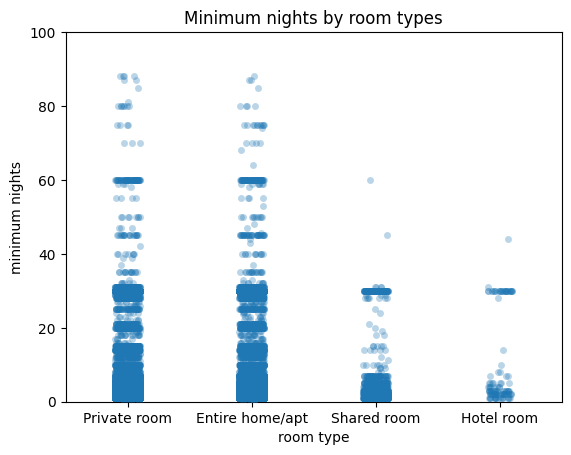

In [ ]:
sns.stripplot(data=df,x="room type",y="minimum nights",alpha=0.3,jitter=True)
plt.ylim(0,100)
plt.title("Minimum nights by room types")

Text(0.5, 1.0, 'Combined revenue by room types')

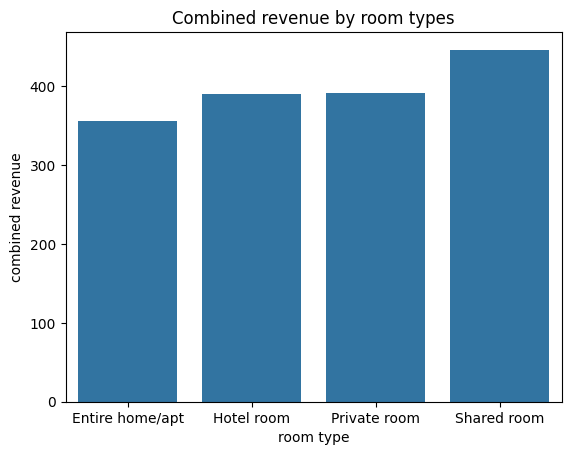

In [ ]:
medianrevenue = df.groupby("room type")["combined revenue"].median().reset_index()
sns.barplot(x= "room type", y = "combined revenue", data = medianrevenue)
plt.title("Combined revenue by room types")

Figure 4 shows that listings with higher minimum nights are mostly entire home/apt and private rooms. Additionally we discover through figure 5 that shared rooms generate the most combined profit which takes in account the minimum nights and the booking frequency throughout the month. This highlights that hotel rooms and shared rooms have a high booking frequency comapred to entire home/apt and private rooms. While entire home/apt and private rooms require longer stays to be profitable, hotel rooms and shared rooms rely on higher pricing and shorter,frequent stays.



> ***Price analysis***





Text(0.5, 1.0, 'Price distribution')

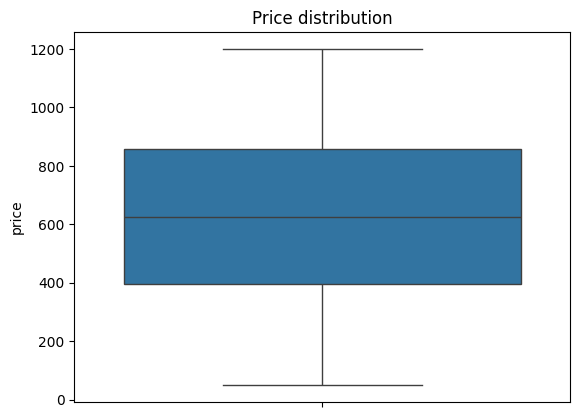

In [ ]:
sns.boxplot(y=df["price"])
plt.title("Price distribution")

The box plot displays the price distribution with a median of 600 and interquartile values ranging from 400-900, with a minimum value of 50 and a maximum of 1200. This shows a high variability in pricing caused by multiple factors as seen below.

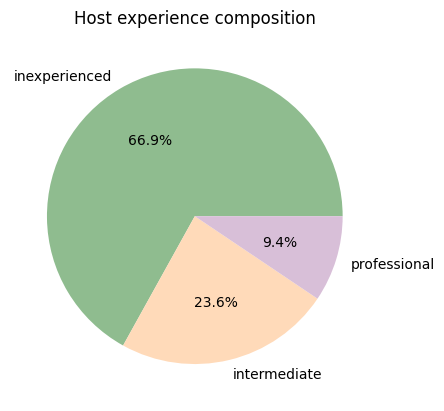

In [ ]:
piecount = df["host_experience"].value_counts()
plt.pie(piecount, labels=piecount.index, autopct='%1.1f%%', startangle=0, colors=["darkseagreen", "peachpuff", "thistle"])
plt.title("Host experience composition")
plt.show()

Text(0.5, 1.0, 'Impact of host experience on price')

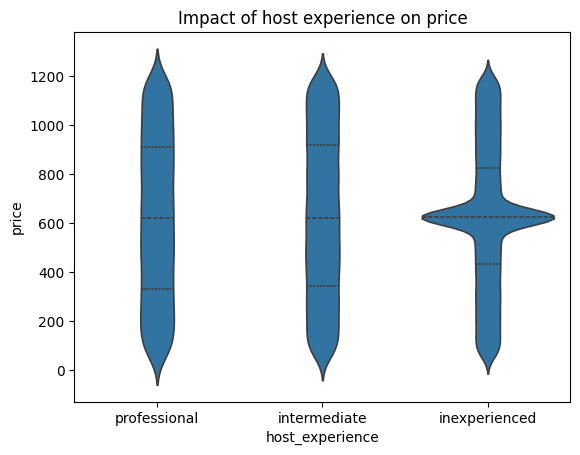

In [ ]:
sns.violinplot(x="host_experience", y="price", data=df, inner="quartile")
plt.title("Impact of host experience on price")

Figure 7 helps explain the price distrubution in figure 6, as inexperienced hosts are the most common host type, with a percentage of 66.9%, followed by intermediate hosts and professional hosts. We can see in figure 8 that the price is concentrated around 600 for inexperienced hosts, who dominate the market. This explains the median value of 600 displayed in figure 6.



>***Combined revenue analysis***



In [ ]:
df["log review score"] = np.log1p(df["Review score"]) # data is skewed
print(df["log review score"].corr(df['combined revenue']))

0.7029320459285976


Text(0.5, 1.0, 'Relationship between review score and price')

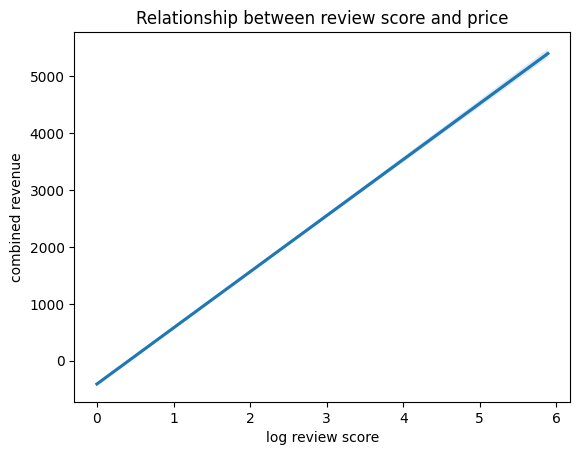

In [ ]:
sns.regplot(x="log review score", y = "combined revenue",data = df,scatter = False)
plt.title("Relationship between review score and price")

Text(0.5, 1.0, 'Average review scores by host experience and room type')

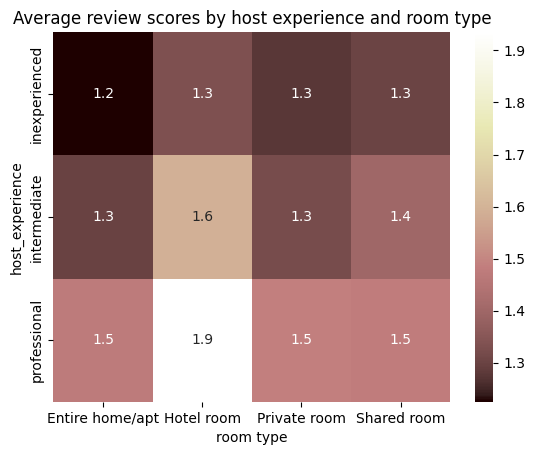

In [ ]:
pivot = df.pivot_table(
    values="log review score",
    index="host_experience",
    columns="room type",
    aggfunc="mean"
)
sns.heatmap(pivot, annot = True, cmap="pink")
plt.title("Average review scores by host experience and room type")

As shown in figure 9, review scores show a positive relation with combined revenue which takes in account the demand, indicating that listings with better review scores attarct more demand, which leads to a higher combined revenue. More importantly, combining this with figure 10 that measures review scores allows us to conclude that inexperienced hosts have lower review scores across all room types, compared to intermediate and professional hosts. Therefore, it limits their ability to earn higher revenues overall.

This could possibly be a reason for the price distrubtion in figure 8. As lower review scores reduce demand, inexperienced hosts may have less freedom pricing higher prices like intermediate and professional hosts and need to stick within a safe price range of 600.



Figure 10 also shows that the effect of experience strongly affects the review scores of hotel rooms indicating that it needs professional mangement to excel.



> ***Trends over time analysis***


Text(0.5, 1.0, 'Activity of AirBnB by recorded number of reviews')

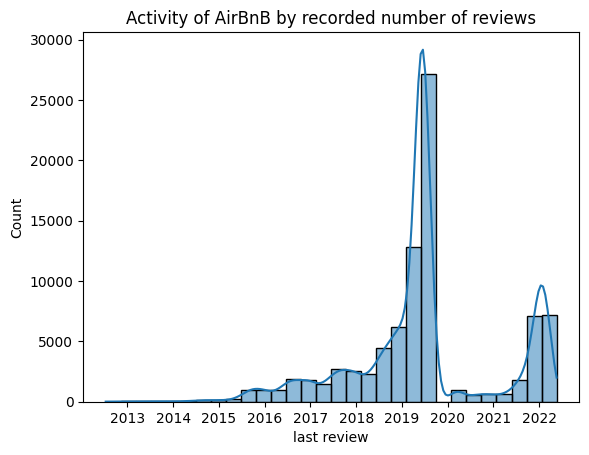

In [ ]:
sns.histplot(df["last review"], bins=30, kde=True)
plt.title("Activity of AirBnB by recorded number of reviews")

This graph can be used to interpret the activity of AirBnB across the years. It shows steady growth throughout 2013-2018, then it took off, reaching it's peak in 2019 with the highest number of recorded last reviews. A  possible reason for this was the launching of "AirBnB experiences" whcich offers actvities programs in addition to the accommodation. However, a huge decline throughout 2019-2021 is observed, most likely due to COVID-19. After 2021, the platform started to regain activity, although never fully recovering.



> ***Reccomendations***



For hosts

1.   Inexperienced hosts should avoid starting their hosting journey by listing hotel rooms as they require experience for a good review score and reputation.
2.   Shared room hosts have the best chance at profit but they should keep in mind to try to meet the guests expectations and satisfaction as they have a low maximum review score.
3. Hosts shouldn't rely on AirBnB as only source of income as crisis like COVID-19 caused a huge decline in market making them financially vulnerable.

For AirBnB


1. AirBnB can work to promote listings in the underrepresented boroughs better to avoid oversaturation and undersaturation.
2. AirBnB can expand by taking over or doing partnerships with hotels to increase its revenues.
3. AirBnB should consider promoting to professional hosts as they have a small proprtion in this dataset and they have the capability to mantain high review scores so this would increase the profits.





